# Detecção de Fraudes em Transações

## Importando Pandas

In [1]:
# utilizando o Pandas com dados(dataset) reais.

import pandas as pd

url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"

df = pd.read_csv(url)

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Problema de classificação desbalanceada

In [2]:
# Calculando a proporção de cada tipo de transação
df["Class"].value_counts(normalize=True)

,proportion
Class,
0,0.998273
1,0.001727


## Feature Engineering

In [4]:
# Nesta etapa criamos(ou alteramos) variaveis para ajudar nosso modelo.
# seria como equilibrar os dados para que o modelo entenda melhor

import numpy as np

df["Amount_log"] = np.log1p(df["Amount"])


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Cria uma nova coluna "Amount_scaled" com os valores da coluna "Amount" padronizados.
# O StandardScaler transforma os dados para que tenham:
# - média = 0
# - desvio padrão = 1
# Isso garante que a variável "Amount" fique na mesma escala das demais,
# evitando que valores muito grandes ou muito pequenos distorçam o treinamento do modelo.
df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])


In [22]:
# Preparando os dados para treinar o modelo

from sklearn.model_selection import train_test_split

# Define as variáveis independentes (X) e a variável alvo (y).
# - X: todas as colunas do DataFrame, exceto "Class"
# - y: a coluna "Class", que representa a variável que queremos prever
x = df.drop("Class", axis=1)
y = df["Class"]

# Divide os dados em conjuntos de treino e teste.
# - x_train, y_train: usados para treinar o modelo
# - x_test, y_test: usados para avaliar o modelo
# - test_size=0.3 → 30% dos dados vão para teste e 70% para treino
# - random_state=42 → garante reprodutibilidade, sempre a mesma divisão
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)


## Logistic Regression

In [8]:
# Criando o modelo de Regressão Logística.
from sklearn.linear_model import LogisticRegression

# - max_iter=1000 → define o número máximo de iterações para o algoritmo convergir.
model = LogisticRegression(max_iter=1000)

# Treina o modelo usando os dados de treino (x_train, y_train).
# O modelo aprende a relação entre as variáveis independentes (X) e a variável alvo (y).
model.fit(x_train, y_train)

# Usa o modelo treinado para prever os valores da variável alvo no conjunto de teste.
# y_pred conterá as previsões feitas pelo modelo com base em x_test.
y_pred = model.predict(x_test)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [10]:
# Relatório de classificação com várias métricas importantes para avaliar o desempenho do modelo
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

# -------------------------------
# O classification_report retorna um resumo com métricas de avaliação do modelo de classificação:
# - precision (precisão): entre todas as previsões positivas, quantas estavam corretas.
# - recall (revocação/sensibilidade): entre todos os casos positivos reais, quantos foram identificados corretamente.
# - f1-score: média harmônica entre precisão e recall, equilibrando as duas métricas.
# - support: número de ocorrências reais de cada classe no conjunto de teste.
#
# Interpretação:
# - Valores próximos de 1 indicam bom desempenho.
# - O relatório mostra essas métricas para cada classe separadamente,
#   além de médias (macro, weighted) que resumem o desempenho geral.


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85307
           1       0.83      0.63      0.72       136

    accuracy                           1.00     85443
   macro avg       0.92      0.82      0.86     85443
weighted avg       1.00      1.00      1.00     85443



### Interpretação dos resultados

#### Classe 0 (não fraude, por exemplo)
  - Precision = 1.00 → todas as previsões de classe 0 estavam corretas.
  - Recall = 1.00 → o modelo identificou todos os casos reais da classe 0.
  - F1-score = 1.00 → equilíbrio perfeito entre precisão e recall.
  
  👉 Isso mostra que o modelo está excelente para a classe majoritária.

#### Classe 1 (fraude, por exemplo)
  - Precision = 0.83 → quando o modelo prevê fraude, 83% das vezes está certo.
  - Recall = 0.63 → mas ele só consegue capturar 63% das fraudes reais.
  - F1-score = 0.72 → desempenho razoável, mas longe do ideal.
  
  👉 Aqui vemos a dificuldade em detectar a classe minoritária, típica em problemas desbalanceados.


#### Accuracy = 1.00
  - Parece perfeito, mas é enganoso: como a classe 0 domina (85.307 exemplos contra apenas 136 da classe 1), o modelo acerta quase tudo só por classificar corretamente a maioria.
  - Por isso, métricas como precision, recall e f1-score são mais relevantes que a acurácia em cenários desbalanceados.


#### Macro avg (0.92 / 0.82 / 0.86)
  - Média simples entre as classes. Mostra que o desempenho geral cai quando consideramos ambas as classes igualmente.


#### Weighted avg (≈1.00)
  - Média ponderada pelo número de exemplos. Como a classe 0 domina, o resultado fica próximo de 1.00, mascarando a dificuldade na classe 1.


#### Pontos de análise
  - O modelo está muito bom para a classe majoritária (0).
  - Está razoável para a classe minoritária (1), mas perde recall (não detecta todas as fraudes).
  - A acurácia alta é ilusória por causa do desbalanceamento.
  - O foco deve ser melhorar o recall da classe minoritária, sem perder muita precisão.


#### Próximos passos possíveis
  - Aplicar técnicas de balanceamento como oversampling, undersampling ou SMOTE.
  - Ajustar class weights na regressão logística para dar mais importância à classe minoritária.
  - Testar modelos avançados como Random Forest ou Gradient Boosting, que podem lidar melhor com desbalanceamento.

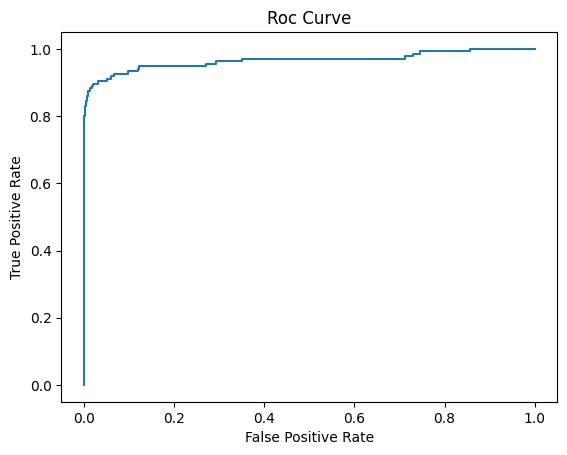

AUC: 0.9659766042232242


In [15]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_probs = model.predict_proba(x_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr)
plt.title("Roc Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

print("AUC:", roc_auc_score(y_test, y_probs))

# -------------------------------
# O código acima avalia o modelo usando a curva ROC e o AUC:
#
# - predict_proba → retorna as probabilidades de cada classe. Selecionamos [:,1] para pegar
#   a probabilidade da classe positiva (fraude, por exemplo).
#
# - roc_curve → calcula os pontos da curva ROC, mostrando a relação entre:
#   * FPR (False Positive Rate) → taxa de falsos positivos
#   * TPR (True Positive Rate) → taxa de verdadeiros positivos
#
# - plt.plot(fpr, tpr) → plota a curva ROC, que ajuda a visualizar a capacidade do modelo
#   em distinguir entre classes.
#
# - roc_auc_score → calcula a área sob a curva ROC (AUC).
#   * AUC próximo de 1 → excelente desempenho
#   * AUC = 0.5 → modelo não melhor que um chute aleatório
#
# Em resumo: a curva ROC mostra o trade-off entre sensibilidade e especificidade,
# e o AUC resume esse desempenho em um único número.


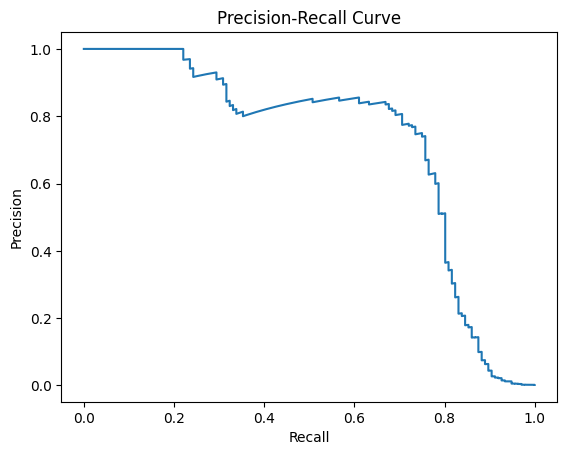

In [16]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, _ = precision_recall_curve(y_test, y_probs)

plt.plot(recall, precision)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

# -------------------------------
# O código acima gera a curva Precision-Recall:
#
# - precision_recall_curve → calcula os pontos da curva mostrando a relação entre:
#   * Precision (precisão): entre todas as previsões positivas, quantas estavam corretas.
#   * Recall (revocação/sensibilidade): entre todos os casos positivos reais, quantos foram identificados corretamente.
#
# - plt.plot(recall, precision) → plota a curva Precision-Recall, útil para visualizar
#   o trade-off entre capturar mais positivos (recall) e manter previsões corretas (precision).
#
# Interpretação:
# - Uma curva mais próxima do canto superior direito indica melhor desempenho.
# - É especialmente relevante em cenários desbalanceados (como fraude), onde a acurácia
#   pode ser enganosa e precisamos avaliar o equilíbrio entre precisão e recall.


## Balanceamento de Dados

In [17]:
# Undersampling
fraudes = df[df["Class"] == 1]   # Seleciona todas as linhas da classe 1 (fraudes)
normais = df[df["Class"] == 0].sample(len(fraudes), random_state=42)
# Seleciona aleatoriamente a mesma quantidade de linhas da classe 0 (normais)
# que existe na classe 1, garantindo equilíbrio entre as classes.

df_under = pd.concat([fraudes, normais])
# Junta os dois subconjuntos (fraudes + normais) em um novo DataFrame balanceado.
#
# Interpretação:
# - O undersampling reduz a quantidade de exemplos da classe majoritária (normais),
#   para igualar ao número da classe minoritária (fraudes).
# - Isso ajuda o modelo a não ficar enviesado para a classe dominante.
# - Porém, como descartamos dados da classe majoritária, podemos perder informação.
# - É uma técnica útil quando o dataset é muito desbalanceado e grande.


In [20]:
# Oversampling com SMOTE
from imblearn.over_sampling import SMOTE

smote = SMOTE()

# Aplica o SMOTE para gerar exemplos sintéticos da classe minoritária.
# - x_res: variáveis independentes após o balanceamento
# - y_res: variável alvo após o balanceamento
x_res, y_res = smote.fit_resample(x, y)

# -------------------------------
# O SMOTE (Synthetic Minority Over-sampling Technique) cria novos exemplos da classe minoritária
# em vez de apenas duplicar os existentes. Ele gera pontos sintéticos interpolando entre
# exemplos reais próximos.
#
# Vantagens:
# - Ajuda a reduzir o desbalanceamento sem descartar dados da classe majoritária.
# - Melhora a capacidade do modelo de aprender padrões da classe minoritária.
#
# Pontos de atenção:
# - Pode introduzir exemplos artificiais que não representam perfeitamente a realidade.
# - É importante avaliar se o modelo não passa a "superajustar" aos dados sintéticos.


In [21]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=50,        # número de árvores na floresta
    max_depth=10,           # profundidade máxima de cada árvore
    class_weight="balanced",# ajusta os pesos das classes para compensar desbalanceamento
    n_jobs=-1,              # usa todos os núcleos disponíveis para acelerar o treino
    random_state=42         # garante reprodutibilidade dos resultados
)

# Treina o modelo com os dados de treino
rf.fit(x_train, y_train)

# Faz previsões no conjunto de teste
y_pred_rf = rf.predict(x_test)

# Gera relatório de classificação com métricas (precision, recall, f1-score, support)
print(classification_report(y_test, y_pred_rf))

# -------------------------------
# Interpretação:
# - O Random Forest combina várias árvores de decisão para melhorar a precisão e reduzir overfitting.
# - O parâmetro class_weight="balanced" é crucial em cenários desbalanceados (como fraude),
#   pois dá mais importância à classe minoritária durante o treino.
# - O classification_report mostra como o modelo performa em cada classe:
#   * Precision → quão confiáveis são as previsões positivas
#   * Recall → quão bem o modelo captura os casos positivos reais
#   * F1-score → equilíbrio entre precisão e recall
#   * Support → quantidade de exemplos reais de cada classe
#
# Esse setup ajuda a melhorar a detecção da classe minoritária sem perder desempenho na majoritária.


              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85307
           1       0.84      0.85      0.84       136

    accuracy                           1.00     85443
   macro avg       0.92      0.92      0.92     85443
weighted avg       1.00      1.00      1.00     85443



## Pipeline

In [23]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("scaler", StandardScaler()),                 # Etapa 1: padroniza os dados (média=0, desvio padrão=1)
    ("model", LogisticRegression(max_iter=1000))  # Etapa 2: aplica regressão logística com até 1000 iterações
])

# Treina o pipeline: primeiro aplica o StandardScaler nos dados de treino,
# depois ajusta o modelo de regressão logística.
pipeline.fit(x_train, y_train)

# Faz previsões no conjunto de teste.
# O pipeline garante que os mesmos passos de pré-processamento (scaler)
# sejam aplicados automaticamente antes da predição.
y_pred = pipeline.predict(x_test)

# -------------------------------
# Interpretação:
# - O Pipeline organiza o fluxo de trabalho em etapas sequenciais.
# - Isso evita erros de consistência, pois garante que o mesmo pré-processamento
#   usado no treino seja aplicado no teste e em novos dados.
# - É uma prática recomendada em machine learning, pois torna o código mais limpo,
#   reprodutível e fácil de manter.


## Threshold

In [ ]:
threshold = 0.3

# Converte probabilidades em previsões binárias usando um limiar customizado.
# - Se a probabilidade da classe positiva (fraude, por exemplo) for maior que 0.3,
#   o modelo classifica como 1 (fraude).
# - Caso contrário, classifica como 0 (não fraude).
y_pred_custom = (y_probs > threshold).astype(int)

# Gera relatório de classificação com métricas (precision, recall, f1-score, support)
print(classification_report(y_test, y_pred_custom))

# -------------------------------
# Interpretação:
# - O threshold padrão da regressão logística é 0.5.
# - Ao reduzir para 0.3, o modelo fica mais "sensível" e passa a detectar mais casos positivos.
#   Isso tende a aumentar o recall (captura mais fraudes), mas pode reduzir a precisão
#   (mais falsos positivos).
# - Ajustar o threshold é uma técnica importante em cenários desbalanceados,
#   pois permite encontrar o ponto ótimo entre recall e precisão.


## XGBoost

In [24]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    scale_pos_weight=10,       # ajusta o peso da classe minoritária para lidar com desbalanceamento
    use_label_encoder=False,   # evita warnings relacionados ao encoder interno do XGBoost
    eval_metric="logloss"      # métrica de avaliação usada durante o treino (log loss)
)

# Treina o modelo com os dados de treino
xgb.fit(x_train, y_train)

# Faz previsões no conjunto de teste
y_pred_xgb = xgb.predict(x_test)

# -------------------------------
# Interpretação:
# - O XGBClassifier é baseado em Gradient Boosting, combinando várias árvores de decisão
#   de forma sequencial para melhorar a performance.
# - O parâmetro scale_pos_weight=10 é usado para dar mais importância à classe minoritária
#   (fraudes, por exemplo). Esse valor geralmente é definido como a razão entre
#   a quantidade de exemplos da classe majoritária e da minoritária.
# - eval_metric="logloss" mede a perda logarítmica, útil para avaliar classificadores binários.
#
# Vantagens:
# - XGBoost costuma ter alta performance em dados tabulares.
# - É robusto contra overfitting e oferece várias opções de regularização.
# - Permite lidar bem com desbalanceamento via scale_pos_weight.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [19:33:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [25]:
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85307
           1       0.94      0.85      0.89       136

    accuracy                           1.00     85443
   macro avg       0.97      0.93      0.95     85443
weighted avg       1.00      1.00      1.00     85443



## Importancia das variáveis

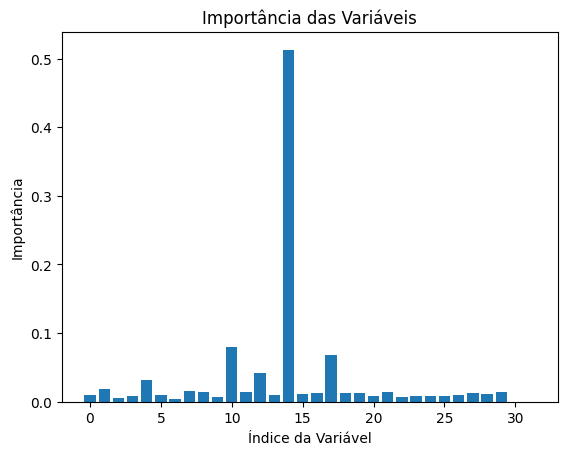

In [26]:
import matplotlib.pyplot as plt

importancias = xgb.feature_importances_

plt.bar(range(len(importancias)), importancias)
plt.title("Importância das Variáveis")
plt.xlabel("Índice da Variável")
plt.ylabel("Importância")
plt.show()

# -------------------------------
# O código acima plota a importância das variáveis no modelo XGBoost:
#
# - xgb.feature_importances_ → retorna um array com a relevância de cada variável
#   usada pelo modelo. Quanto maior o valor, mais impacto aquela variável teve
#   nas decisões das árvores.
#
# - plt.bar(...) → cria um gráfico de barras mostrando a importância relativa
#   de cada variável pelo seu índice (posição no dataset).
#
# Interpretação:
# - As variáveis com maior importância são aquelas que mais contribuíram
#   para separar as classes (ex: fraude vs não fraude).
# - Esse gráfico ajuda a entender quais features são mais influentes,
#   trazendo mais explicabilidade ao modelo.
# - É útil para análise exploratória, seleção de variáveis e comunicação
#   dos resultados para stakeholders.


## Ajuste de hiperParametros

In [28]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "max_depth": [3, 5],        # profundidade máxima das árvores
    "n_estimators": [50, 100]   # número de árvores no ensemble
}

grid = GridSearchCV(
    XGBClassifier(eval_metric="logloss"), # modelo base
    param_grid,                           # grade de parâmetros a testar
    scoring="recall",                     # métrica usada para escolher o melhor modelo
    cv=3                                  # validação cruzada com 3 folds
)

# Treina o GridSearchCV: testa todas as combinações de parâmetros
# e escolhe a que maximiza o recall.
grid.fit(x_train, y_train)

print("Best Model:", grid.best_params_)

# -------------------------------
# Interpretação:
# - O GridSearchCV percorre todas as combinações de parâmetros definidos em param_grid.
# - Para cada combinação, ele treina o modelo e avalia usando validação cruzada (cv=3).
# - O parâmetro scoring="recall" indica que queremos maximizar o recall,
#   ou seja, capturar o maior número possível de casos positivos (fraudes).
# - grid.best_params_ retorna os hiperparâmetros que tiveram melhor desempenho.
#
# Vantagens:
# - Automatiza a busca por hiperparâmetros ideais.
# - Garante que a escolha seja baseada em métricas relevantes (nesse caso, recall).
# - Ajuda a melhorar o desempenho do modelo sem precisar de ajustes manuais.


Best Model: {'max_depth': 3, 'n_estimators': 100}


## Explicabilidade

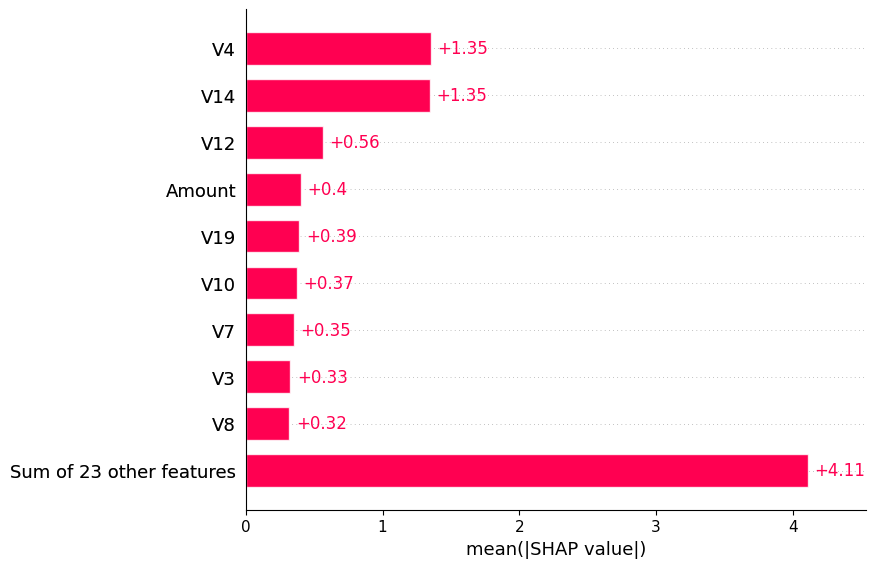

In [33]:
import shap   # importa a biblioteca SHAP
explainer = shap.Explainer(xgb)              # Cria o explicador SHAP para o modelo treinado
shap_values = explainer(x_test[:100])        # Calcula os valores SHAP para 100 amostras do conjunto de teste

shap.plots.bar(shap_values)                  # Plota gráfico de barras com a importância média das variáveis

# -------------------------------
# O SHAP é uma técnica de interpretabilidade que mostra quanto cada variável contribui
# para a previsão do modelo em cada exemplo.
#
# - shap.Explainer(xgb) → cria um objeto que sabe como calcular os valores SHAP para o modelo XGBoost.
# - shap_values → contém os valores SHAP, que representam a contribuição de cada feature
#   para a saída do modelo em cada amostra.
# - shap.plots.bar → gera um gráfico de barras mostrando a importância média das variáveis
#   (quanto elas influenciam positivamente ou negativamente nas previsões).
#
# Interpretação:
# - Variáveis com barras maiores são as que mais impactam as decisões do modelo.
# - Esse gráfico ajuda a entender quais features são mais relevantes para explicar
#   as previsões, trazendo transparência e confiança ao modelo.
